In [ ]:
import torch
import utils
from pathlib import Path
import preprocess_data as ppd
from process_session import session as ss
import process_probe as pp
import process_attribution as pa
import numpy as np
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# Session obj contains stimulus, channel, and unit information
session_id = 1044385384
session_obj = ss(session_id)

In [4]:
# Spikes obj contains Spike matrix
spikes_obj = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=0.004, sigma=3)
spikes_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[1])
spikes_obj.convolve_with_gaussian()
spikes_obj.zscore()

100%|██████████| 741/741 [01:24<00:00,  8.81it/s]


In [5]:
# Probe obj contains LFP data
# Getting LFP just for active trials
probe_obj = pp.probe(session_obj, session_obj.active_times[0], session_obj.active_times[1])
lfp_obj = ppd.pre_process_lfp(probe_obj.lfp, 1250)
lfp_obj.filter_lfp(probe_obj.bands)

c:\Users\Marisol\anaconda3\envs\allensdk\lib\site-packages\hdmf\utils.py:668: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  return func(args[0], **pargs)
c:\Users\Marisol\anaconda3\envs\allensdk\lib\site-packages\hdmf\utils.py:668: UserWarning: Ignoring cached namespace 'core' version 2.5.0 because version 2.6.0-alpha is already loaded.
  return func(args[0], **pargs)
c:\Users\Marisol\anaconda3\envs\allensdk\lib\site-packages\hdmf\utils.py:668: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  return func(args[0], **pargs)
100%|██████████| 8/8 [04:37<00:00, 34.71s/it]


In [6]:
import importlib
importlib.reload(ppd)
import plots

In [15]:
# Training hyperparameters
input_size = spikes_obj.spkMat.shape[1]
hidden_size = 50 # temp value, don't have gpu so just to make sure everything works
num_layers = 1
seqlength = 750
num_epochs = 15 # temp value, just to make sure everything works w/o bugs
X_train, y_train, X_test, y_test = ppd.generate_training_data(lfp_obj, spikes_obj, seqlength)

In [16]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([720000, 741]),
 torch.Size([720000, 20, 9]),
 torch.Size([180750, 741]),
 torch.Size([180750, 20, 9]))

In [13]:
models, lossesAll = utils.train_models(probe_obj, input_size, hidden_size, num_layers, seqlength, device, num_epochs, X_train, y_train)

 10%|█         | 2/20 [02:24<21:43, 72.39s/it]


KeyboardInterrupt: 

In [24]:
# Saving model weights
output_dir = Path('F:/vbn_s3_cache/test')
utils.save_models(models, output_dir, session_id)

In [17]:
# Loading model weights
output_dir = Path(r"Z:\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022")
args = [input_size, hidden_size, num_layers, seqlength, device]
models = utils.load_models(output_dir, session_id, probe_obj, args)

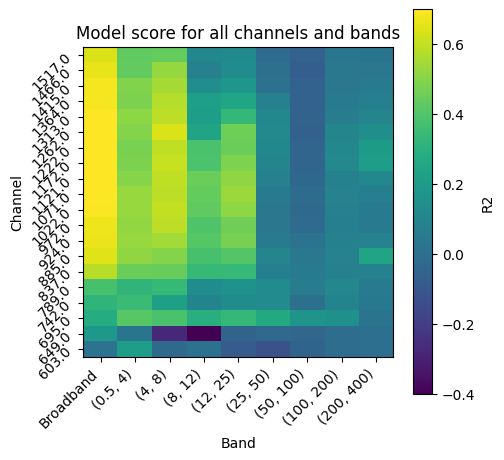

In [22]:
plots.plot_test_loss(models, X_test, y_test, probe_obj)

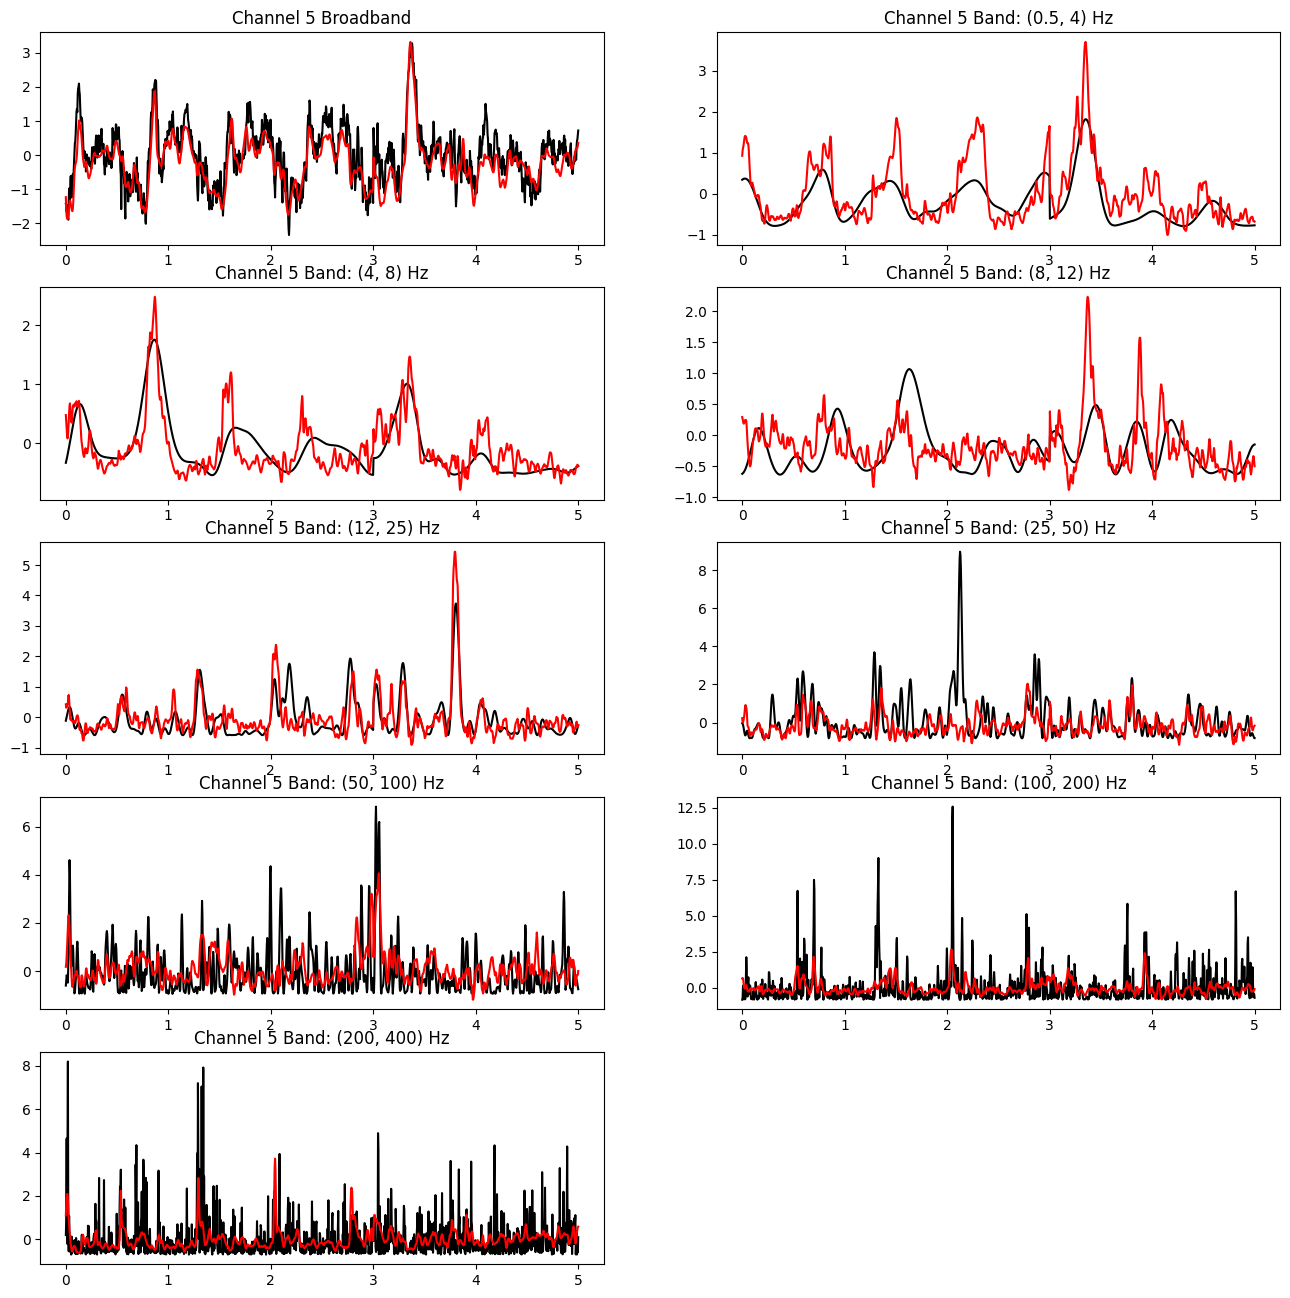

In [23]:
plots.plot_lfp_prediction(models, X_test, y_test, probe_obj.bands, chani=5)

In [27]:
# Calculating and saving attribution scores
output_dir = Path(r'F:\vbn_s3_cache\test')
dur = 7 # temp value, just to make sure everything works w/o bugs
bin_size = 0.004
pa.divide_task_for_attr(models, session_id, output_dir, spikes_obj, bin_size, probe_obj, dur)